<a href="https://colab.research.google.com/github/49262532M/Procesos-Estoc-sticos/blob/main/Simulaciones_GPs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **PRÁCTICA 2: SIMULAR Y VISUALIZAR GPs**

In [1]:
# Importamos librerías básicas que utilizaremos
import numpy as np
import matplotlib.pyplot as plt
import math

## **Ejercicio 1: Muestras de una normal multivariante / multidimensional**

En la siguiente celda se deben obtener 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$ que sigue una distribución normal $\mathcal{N}(0,I_{3\times 3})$

Para ello, utilizamos la función `np.random.multivariate_normal`

In [2]:
vector_medias = [0, 0, 0]
#ya que por la distribución dada su media será el vector nulo de dimensión 3
matriz_covarianzas = np.eye(3)
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, size=num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[-0.90211427  0.3855507   0.83388043]
 [ 1.57763346  1.60964392  1.46988954]
 [-0.58570871  0.52336725  0.15986784]
 [-1.0396727   0.47820527 -0.47058579]
 [ 0.93639028  0.11039668  0.93945519]
 [-0.96343796 -0.06876751 -0.29107097]
 [ 1.81340958  0.61357651 -0.40518319]
 [ 1.56649754  0.07180073  1.25006474]
 [-0.9921716   0.69402763  0.19427348]
 [ 0.08476555  0.11278273  0.67040033]
 [-0.28558151 -0.6236053  -0.30565624]
 [ 0.61888606  1.38441347 -1.46875793]
 [ 1.04900031 -1.06495948  0.85394962]
 [ 0.21102121 -0.85842081  2.15126433]
 [-0.12616257  0.79169171  0.73175296]
 [-0.27592686  1.41935913  0.99886722]
 [ 0.00351317  1.15402725 -0.85787216]
 [ 0.39207219  0.81498636  0.3054917 ]
 [-0.09056722  0.69927374 -0.07739299]
 [-1.08023758 -0.18450862  0.79396269]
 [-0.83378228  1.63990842 -0.44395207]
 [-1.20632482  0.53737739 -0.82840845]
 [ 0.63731907  0.27257437 -0.8317816 ]
 [-0.19661092 -2.62012041  1.03939277]
 [ 0.56626582  0.4476266   1.17585837

Haz ahora lo mismo pero para una normal con matriz de covarianzas que no sea la identidad, sino por ejemplo $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

Puedes simplificar algo el código si usas la función `np.diag`.

¿Qué diferencias esperarías ver en las muestras obtenidas?


Antes de ejecutar el código, veamos las diferencias que esperamos cambiando la matriz de covarianzas, poniendo a cada variable una variabilidad.

En el caso de la primera componente tendrá valores cercanos a 0 y poco variados. En el caso de la segunda variará mas y la tercera columna serán numeros más grandes. Es decir cada variable será mas grande que la anterior debido a este cambio de la variabilidad, lo que conlleva que será también más dispersa.

In [3]:
vector_medias = [0, 0, 0]
matriz_covarianzas = np.diag([1, 10, 100])
#Con la función 'np.diag' ponemos los elementos de la diagonal ordenados.
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, size=num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[-1.44229886e+00 -3.95196053e-01 -1.00106240e+01]
 [ 3.16381733e-01  2.39075063e+00  1.40944949e+00]
 [-1.67435156e+00 -4.66928721e-01  3.34894173e-01]
 [-3.25231674e-01  8.37855753e+00 -1.31033477e+00]
 [ 7.50619521e-01 -3.81553690e+00 -8.53387365e+00]
 [-1.91741914e+00 -5.20778750e+00  1.54594124e+00]
 [ 8.76504231e-01 -2.83787496e+00  2.32551419e+00]
 [ 2.19503954e-01 -4.58039233e+00 -5.75550830e+00]
 [-8.87017017e-01  1.60933183e+00 -1.92339641e+01]
 [ 7.29519359e-01 -1.18506900e-01  8.39458216e+00]
 [-1.20802765e+00  3.91134505e+00  1.09433944e+01]
 [ 5.59891443e-01  3.95340123e+00 -2.35301242e+00]
 [-3.16923443e+00  2.30843421e+00  1.18258188e+01]
 [-5.90102689e-01 -1.91363233e+00  4.69412770e+00]
 [ 1.76337951e-02 -6.83027866e-01 -2.09763504e+01]
 [-3.24150249e-01  4.00510510e+00  2.53344844e+00]
 [-3.15608661e-01  3.46675293e+00  8.39893645e+00]
 [-5.85680069e-01 -1.37815776e+00  5.77271783e+00]
 [-7.01720941e-03  4.68836740e+00  2.06668490e+00]
 [-2

## **Ejercicio 2: Simular un GP con kernel RBF**

En esta sección vamos a definir una función simular_GP_RBF que nos permita simular de un GP con kernel RBF. Y a continuación la usamos para generar imágenes similares a las de las diapositivas 59 y 62. Usaremos función de medias constantemente igual a cero.

In [4]:
def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
    """
    Simular un GP con kernel RBF.

    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    sigma_sq: varianza del kernel. Float.
    lengthscale: parámetro de escala del kernel. Float.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).
    """

    # Paso 1: calcula el vector de medias usando np.zeros_like
    vector_medias = np.zeros_like(t)

    # Paso 2: calcula la matriz de covarianzas usando la vectorización de numpy y la idea de broadcasting que se comentó en la intro a numpy.

    #Crearemos una matriz con todas las diferencias ti-tj usando la idea del broadcasting.
    matriz_de_diferencias= (t[:, None] - t[None, :])
    #Utilizo el 'np.exp' para aplicar la fórmula del kernel RBF; y el 'sigma_sq' que escala la covarianza con la varianza de kernel.
    matriz_covs = sigma_sq * np.exp(-(matriz_de_diferencias**2) / (2 * lengthscale**2))

    # Paso 3: obtén las muestras/simulaciones del GP utilizando np.random.multivariate_normal
    samples = np.random.multivariate_normal(mean=vector_medias,cov=matriz_covs,size=num_samples)

    return samples

Ahora utilizaremos esta función para generar imágenes similares a las de las diapositivas 59 y 62. Para ello, genera las trayectorias con la función recién definida, simular_GPS_RBF, y píntalas con plt.plot.Para generar el grid usamos la función np.linspace en este caso (0,5,100) ya que crea 100 puntos igualmente espaciados entre 0 y 5 tal y como vemos en las diapositivas.

Opcional: si quieres tener diferentes ejes (subplots) en la misma figura, como se hace en las diapositivas 59 y 62, puedes mirar cómo usar plt.subplots.

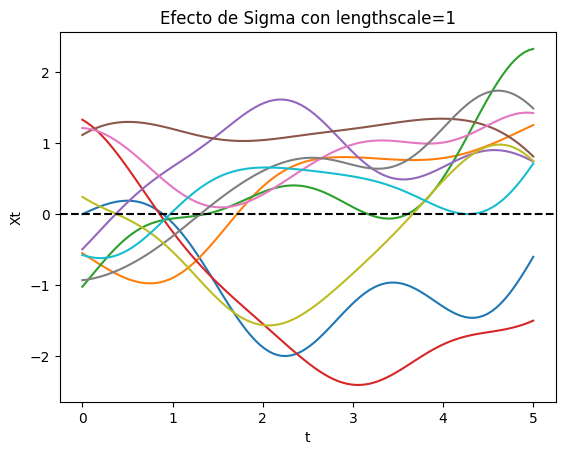

In [5]:
#REPRESENTACIÓN DIAPOSITIVA 59 SOLO CON UN EJE
np.random.seed(1)

t = np.linspace(0, 5, 100)
muestras = simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=10)

for i in range(muestras.shape[0]):
    plt.plot(t, muestras[i])

plt.axhline(0, color='k', linestyle='--')
plt.xlabel('t')
plt.ylabel('Xt')
plt.title('Efecto de Sigma con lengthscale=1')
plt.show()

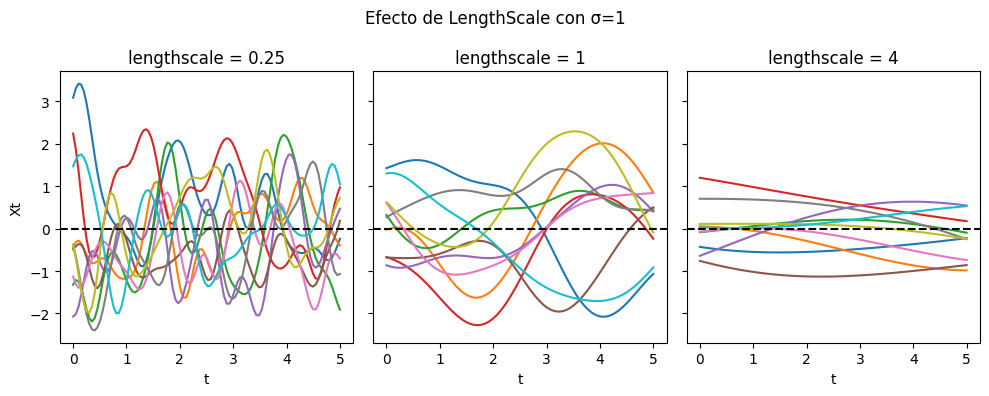

In [6]:
#REPRESENTACIÓN DIAPOSITIVA 62 CON DOS EJES
np.random.seed(1)

t = np.linspace(0, 5, 100)
lengthscales = [0.25, 1, 4]
num_samples=10

fig, axs = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
#Cuando únicamente pones 'plt.subplots(1, 3)' las gráficas salen muy pequeñas y cada una tiene un eje distinto. Por lo que añadiendo figsize=(10,4) tienen un tamaño mejor, y
#añadiendo además sharey=True conseguiremos que los 3 subplots compartan el mismo eje para poder comparar las trayectorias

for ax, ell in zip(axs, lengthscales):
    muestras = simular_GP_RBF(t, sigma_sq=1, lengthscale=ell, num_samples=10)
    for i in range(num_samples):
        ax.plot(t, muestras[i])
    ax.axhline(0, color='k', linestyle='--')
    ax.set_title(f'lengthscale = {ell}')
    ax.set_xlabel('t')

axs[0].set_ylabel('Xt')
fig.suptitle('Efecto de LengthScale con σ=1')
fig.tight_layout()
plt.show()

## **Ejercicio 3: Simular un GP con kernel periódico**

En esta sección vamos a definir una función `simular_GP_periodic` que nos permita simular un GP con kernel periódico. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [7]:
def simular_GP_periodic(t, sigma_sq=1, lengthscale=1, period=1, num_samples=1):
    """
    Simular un GP con kernel periódico y media cero.

    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    sigma_sq: varianza del kernel. Float.
    lengthscale: parámetro de escala del kernel. Float.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).
    """

    vector_medias = np.zeros_like(t)
    matriz_de_diferencias = t[:, None] - t[None, :]
    matriz_covs = sigma_sq * np.exp(-2 * (np.sin(np.pi * np.abs(matriz_de_diferencias) / period) ** 2) / (lengthscale ** 2))

    samples = np.random.multivariate_normal(mean=vector_medias, cov=matriz_covs, size=num_samples)

    return samples

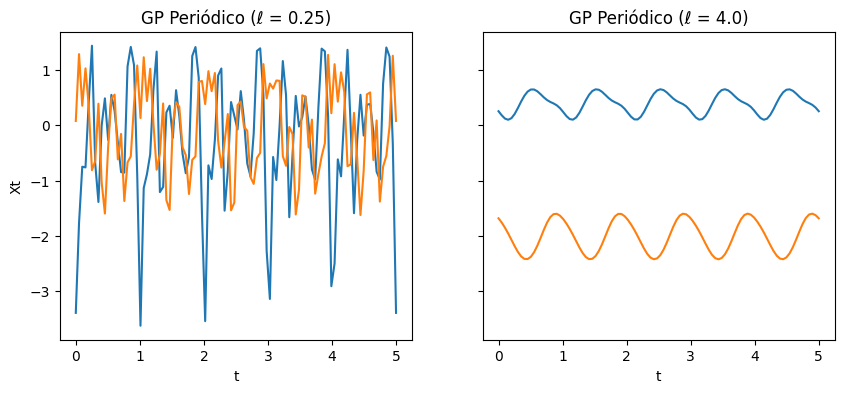

In [13]:
#HAGO LA FUNCIÓN PARA REPRESENTAR LA DIAPOSITIVA 72
np.random.seed(1)
t = np.linspace(0, 5, 100)
lengthscales = [0.25, 4.0]
num_samples=2

fig, axs = plt.subplots(1, 2, figsize=(10, 4),sharey=True)

for ax, ell in zip(axs, lengthscales):
    muestras = simular_GP_periodic(t, sigma_sq=1, lengthscale=ell, period=1, num_samples=num_samples)

    for m in muestras:
        ax.plot(t, m)
    ax.set_title(f'GP Periódico (ℓ = {ell})')
    ax.set_xlabel('t')

axs[0].set_ylabel('Xt')
plt.show()

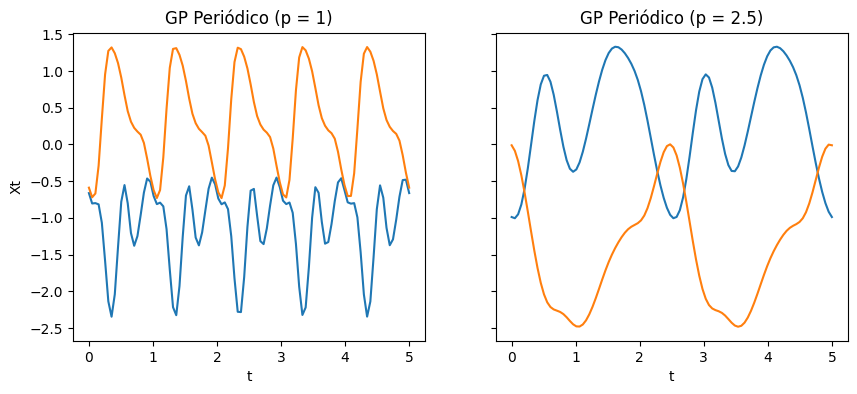

In [12]:
#HAGO LA FUNCIÓN PARA REPRESENTAR LA DIAPOSITIVA 74
np.random.seed(1)
t = np.linspace(0, 5, 100)
periodos = [1, 2.5]
num_samples = 2
lengthscale = 1

fig, axs = plt.subplots(1, 2, figsize=(10, 4),sharey=True)

for ax, p in zip(axs, periodos):
    muestras = simular_GP_periodic(t,sigma_sq=1,lengthscale=lengthscale,period=p,num_samples=num_samples)

    for m in muestras:
        ax.plot(t, m)
    ax.set_title(f'GP Periódico (p = {p})')
    ax.set_xlabel('t')

axs[0].set_ylabel('Xt')
plt.show()

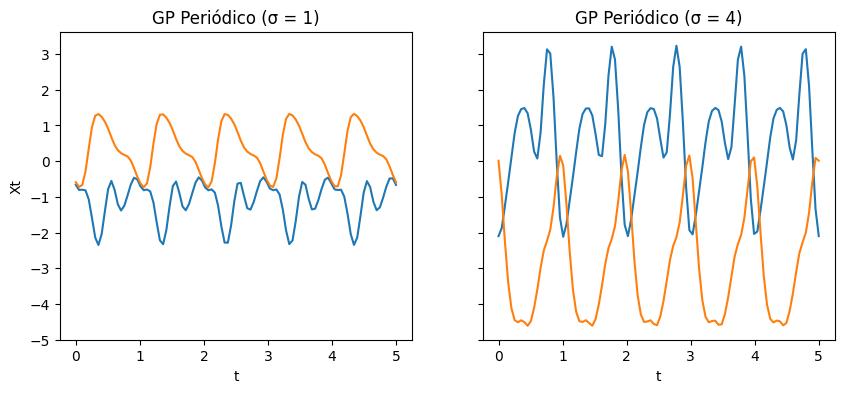

In [11]:
#HAGO LA FUNCIÓN PARA REPRESENTAR LA DIAPOSITIVA 76
np.random.seed(1)
t = np.linspace(0, 5, 100)
sigmas = [1, 4]
num_samples = 2
lengthscale = 1
period = 1

fig, axs = plt.subplots(1, 2, figsize=(10, 4),sharey=True)

for ax, sigma in zip(axs, sigmas):
    muestras = simular_GP_periodic(t,sigma_sq=sigma,lengthscale=lengthscale,period=period,num_samples=num_samples)

    for m in muestras:
        ax.plot(t, m)
    ax.set_title(f'GP Periódico (σ = {sigma})')
    ax.set_xlabel('t')

axs[0].set_ylabel('Xt')
plt.show()

## **Ejercicio 4: Simular un GP con kernel DPK (concretamente polinómico hasta grado m)**

En esta sección vamos a definir una función `simular_GP_DPKpoly` que nos permita simular de un GP con kernel DPK. Concretamente, un kernel DPK con funciones base $1$, $t$, $\dots$, $t^m$. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [14]:
def simular_GP_DPKpoly(t, m=1, num_samples=1):
    """
    Simular un GP con kernel DPK con funciones base 1, t, ..., t^m.

    Input:
    t: vector de localizaciones.Numpy array de shape (n,)
    m: grado máximo del polinomio. Int.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: array de shape (num_samples, n)

    """
    n = len(t)

    # Paso 1: calcula el vector de medias.
    vector_medias = np.zeros(n) # Shape: (n,)

    # Paso 2: calcular la matriz de covarianzas, con el producto matricial F*F^T visto en la diapositiva 82.
    # Para ello construyo la matriz X = [1, t, t^2, ..., t^m] y luego la multiplico por su traspuesta.
    X = np.column_stack([t**k for k in range(m + 1)])   # Shape: (n, m+1)
    matriz_covs = X @ X.T

    # Añado un pequeño jitter por estabilidad numérica
    matriz_covs = matriz_covs + 1e-9 * np.eye(n)


    # Paso 3: obtén las muestras/simulaciones del GP
    samples = np.random.multivariate_normal(mean=vector_medias,cov=matriz_covs,size=num_samples)

    return samples

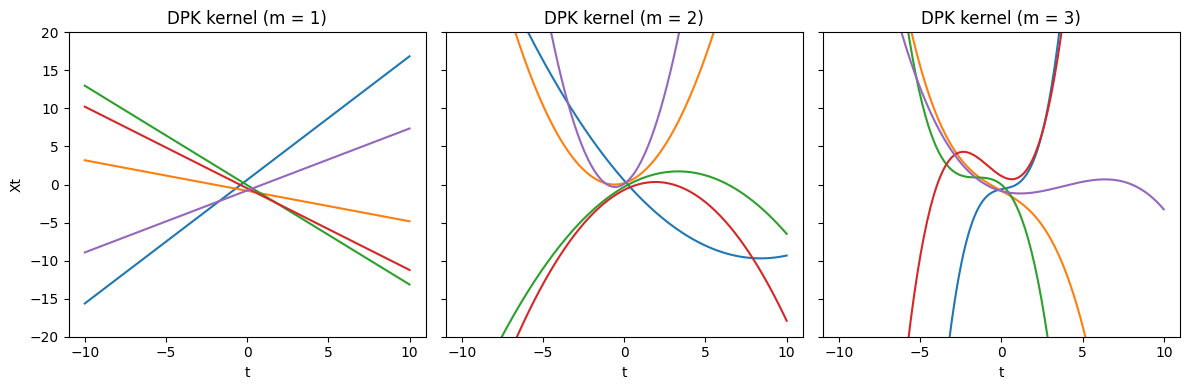

In [15]:
# HAGO LA FUNCIÓN PARA REPRESENTAR LA DIAPOSITIVA 89
np.random.seed(1)

t = np.linspace(-10, 10, 200)
grados = [1, 2, 3]
num_samples = 5

fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, m in zip(axs, grados):
    muestras = simular_GP_DPKpoly(t, m=m, num_samples=num_samples)

    for muestra in muestras:
        ax.plot(t, muestra)

    ax.set_title(f'DPK kernel (m = {m})')
    ax.set_xlabel('t')
    ax.set_ylim(-20, 20)  # importante para que se vea como en la imagen

axs[0].set_ylabel(r'Xt')

plt.tight_layout()
plt.show()

## **Ejercicio 5 Opcional: ¿Cómo hacer que el kernel se pase como parámetro? ¿Y la función de medias?**

Estas preguntas, bastante generales, se pueden abordar de muchas maneras. En esta sección se presenta muy brevemente una solución basada en el paradigma de programación orientada a objetos (POO). Es la manera más habitual de programar en Python y en muchos otros lenguajes.

La idea de la POO es estructurar el código usando el concepto de _clase_. Una _clase_ es algo ``parecido'' a un _struct_, que probablemente se viese en las asignaturas de C++, aunque una clase tiene mayor funcionalidad. Concretamente, una _clase_ es una estructura que nos permite crear objetos que contienen dos cosas principalmente:
* Atributos: valores que forman parte del objeto.
* Métodos: acciones que puede realizar el objeto.

A continuación definimos una _clase_ para describir el kernel RBF. La clase define dos atributos:
* ```self.sigma_sq```: es el parámetro $\sigma^2$.
* ```self.lengthscale```: es el parámetro $\ell$.
Y la clase define un método (además del ```__init__``` básico, que se usa para crear un objeto de la clase):
* ```__call__(self, t, s)```: permite evaluar el kernel usando como inputs los arrays t y s. Es decir, calcula la matriz $(k(t_i, s_j))_{ij}$.

In [16]:
class RBF:
  def __init__(self, sigma_sq=1, lengthscale=1):
    self.sigma_sq = sigma_sq
    self.lengthscale = lengthscale
  def __call__(self, t, s):
    dists = t[:, None] - s[None, :]
    cov_matrix = self.sigma_sq * np.exp(-0.5 * (dists / self.lengthscale)**2)
    return cov_matrix

En la celda anterior simplemente hemos definido "qué es un objeto de tipo RBF".

En la celda siguiente, utilizamos la clase recién definida para crear un objeto concreto de ese tipo:

In [17]:
my_kernel = RBF(sigma_sq=1, lengthscale=1)
print(type(my_kernel))  # Deberíamos ver que este objeto es de tipo "RBF"

t = np.linspace(0,10,100)
cov_mat = my_kernel(t,t)   # Aquí estamos usando el método __call__ (es un método especial que se utiliza de esta manera)
print(cov_mat.shape)  # Aquí deberíamos obtener una matriz con shape (100, 100), puesto que es la matriz de covarianzas de evaluar el GP en t (que tiene tamaño 100)

<class '__main__.RBF'>
(100, 100)


A continuación definimos una clase para la función de medias constantemente igual a cero:

In [18]:
class Zero_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return np.zeros_like(t)

Y creamos un objeto de ese tipo:

In [19]:
my_mf = Zero_Mean_Function()
print(type(my_mf))

mean = my_mf(t)
print(mean.shape)
print((mean==0).all())

<class '__main__.Zero_Mean_Function'>
(100,)
True


Definimos ahora una función ```simular_GP``` que recibe como parámetros __cualquier función de medias__ (```mf```) y __cualquier kernel__ (```kernel```). Lo único que necesitamos es que sean objetos de clases en las que se haya definido el método ```__call__``` igual que se ha hecho arriba.

In [20]:
def simular_GP(t, mf, kernel, num_samples=1):
  vector_medias = mf(t)
  matriz_covs = kernel(t,t)
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)
  return samples

Para validar esta función, vamos a generar la imagen de la diapositiva 64, donde se usaba la función de medias identidad y el kernel RBF.

Para ello, definimos una clase para la función de medias identidad:

In [21]:
class Identity_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return t

Finalmente, usamos esta clase, la clase RBF, y la función ```simular_GP``` para obtener lo buscado:

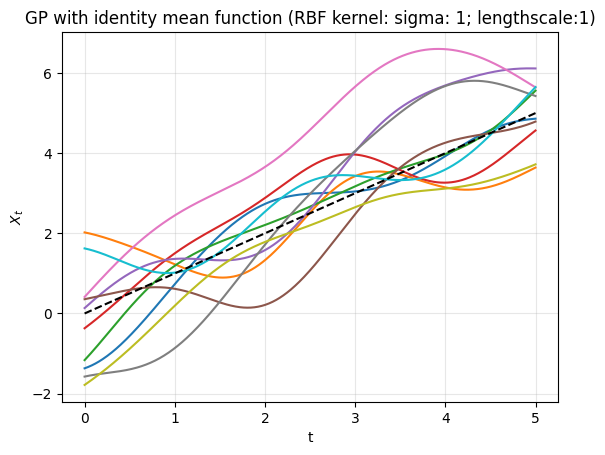

In [22]:
my_identity_mf = Identity_Mean_Function()
sigma = 1
lengthscale = 1
my_rbf_kernel = RBF(sigma_sq=sigma**2, lengthscale=lengthscale)
t = np.linspace(0,5,500)
num_samples = 10
samples = simular_GP(t, my_identity_mf, my_rbf_kernel, num_samples=num_samples)

for i in range(num_samples):
  plt.plot(t, samples[i,:])
plt.plot(t, my_identity_mf(t), color='black', linestyle="--")
plt.title(f"GP with identity mean function (RBF kernel: sigma: {sigma}; lengthscale:{lengthscale})")
plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.grid(True, alpha=0.3)
plt.show()
